# Linear Regression

## Overview

**Linear Regression** is one of the oldest and most widely used statistical learning methods. It models the relationship between one or more input features and a continuous target variable by fitting a linear function to the data. Despite its simplicity, it remains a powerful baseline and is the foundation for many advanced methods.

---

## Problem Formulation

Given a dataset of $n$ samples with $p$ features, linear regression models the target as:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \cdots + w_p x_p + b$$

The goal is to find weights $\mathbf{w}$ and bias $b$ that minimize the **Mean Squared Error (MSE)** loss:

$$\mathcal{L}(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

---

## Two Solvers

### 1. Normal Equation (Closed-Form)

By setting the gradient of the loss to zero and solving analytically:

$$\boldsymbol{\theta} = (X^\top X)^{-1} X^\top \mathbf{y}$$

where $\boldsymbol{\theta} = [b, w_1, \dots, w_p]^\top$ and $X$ is augmented with a column of ones. This gives the **exact global minimum** in one step. It requires matrix inversion, which is $O(p^3)$ — practical for small feature sets but expensive for large ones.

### 2. Gradient Descent (Iterative)

Weights are updated iteratively in the direction of steepest descent:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \mathbf{w} - \frac{2\eta}{n} X^\top (\hat{y} - y)$$

$$b \leftarrow b - \eta \cdot \frac{\partial \mathcal{L}}{\partial b} = b - \frac{2\eta}{n} \sum(\hat{y} - y)$$

This scales to large datasets and avoids matrix inversion entirely.

---

## Evaluation: R² Score

The **coefficient of determination** measures how much variance in $y$ the model explains:

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

- $R^2 = 1.0$ → perfect fit  
- $R^2 = 0.0$ → model predicts the mean  
- $R^2 < 0$ → model is worse than predicting the mean

---

## Assumptions

| Assumption | Description |
|---|---|
| **Linearity** | Relationship between features and target is linear |
| **Independence** | Observations are independent of each other |
| **Homoscedasticity** | Constant variance of residuals |
| **Normality of errors** | Residuals are approximately normally distributed |

---

## Normal Equation vs Gradient Descent

| | Normal Equation | Gradient Descent |
|---|---|---|
| **Solution** | Exact, closed-form | Approximate, iterative |
| **Complexity** | $O(p^3)$ — slow for large $p$ | $O(n \cdot p)$ per iteration |
| **Hyperparameters** | None | Learning rate, iterations |
| **Best for** | Small datasets, few features | Large datasets, many features |

 EXPERIMENT 1 — 1D Regression Line


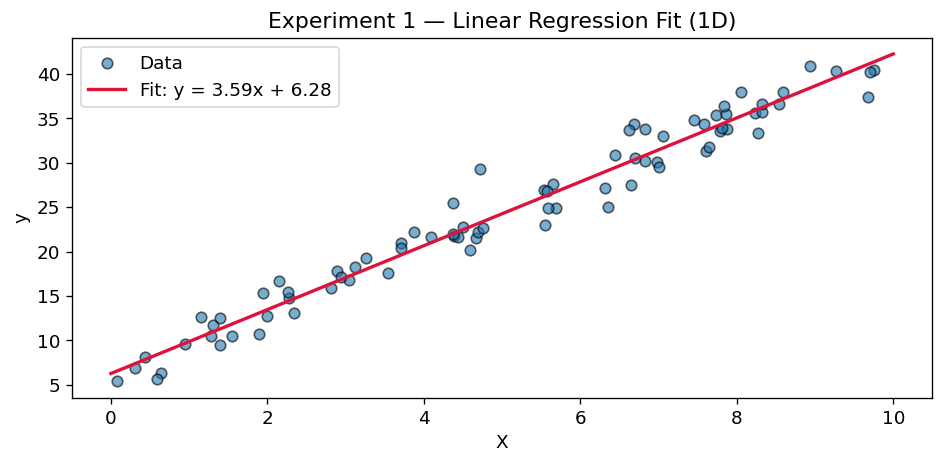

Learned weight : 3.5931  (true: 3.5)
Learned bias   : 6.2820  (true: 7.0)
R²             : 0.9650

 EXPERIMENT 2 — Normal Equation vs Gradient Descent


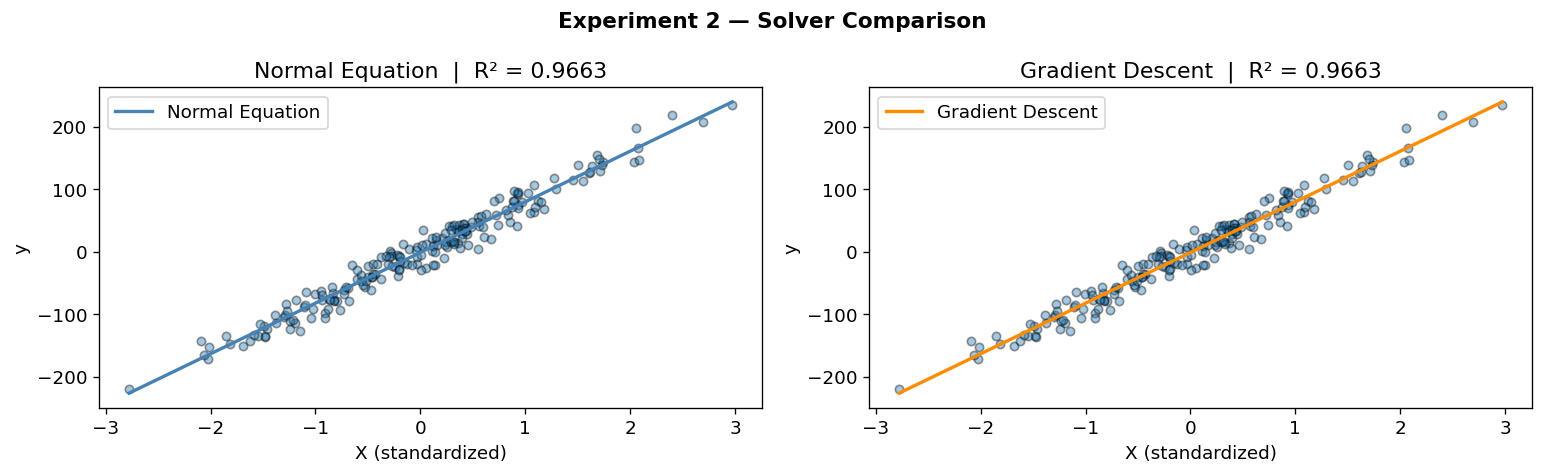

Normal Equation  — weight: 80.9627, bias: -1.4117, R²: 0.9663
Gradient Descent — weight: 80.9627, bias: -1.4117, R²: 0.9663

 EXPERIMENT 3 — Loss Convergence


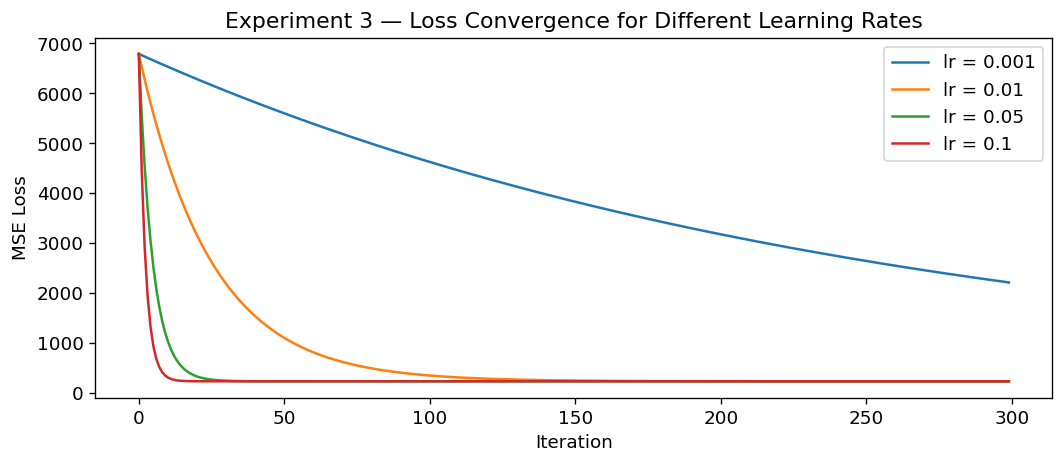

 EXPERIMENT 4 — California Housing Dataset
Feature  : Median Income (MedInc)
R²       : 0.4589
MSE      : 0.7091
RMSE     : 0.8421



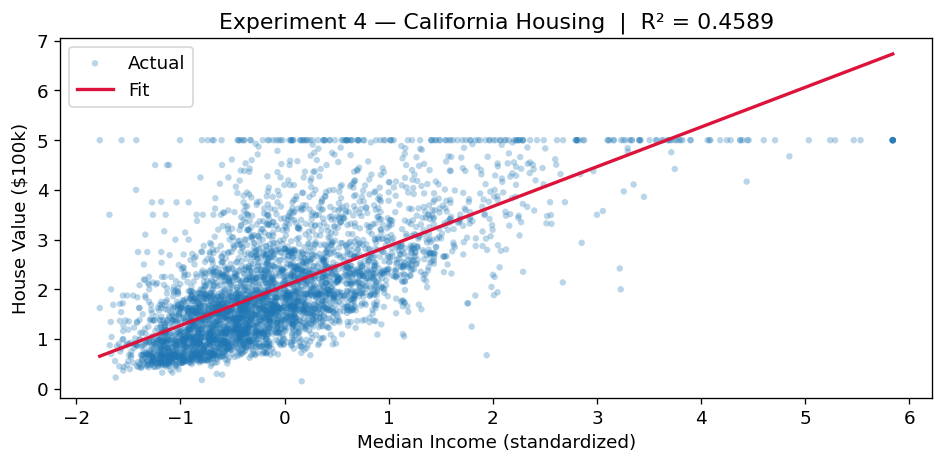

 EXPERIMENT 5 — Residual Analysis


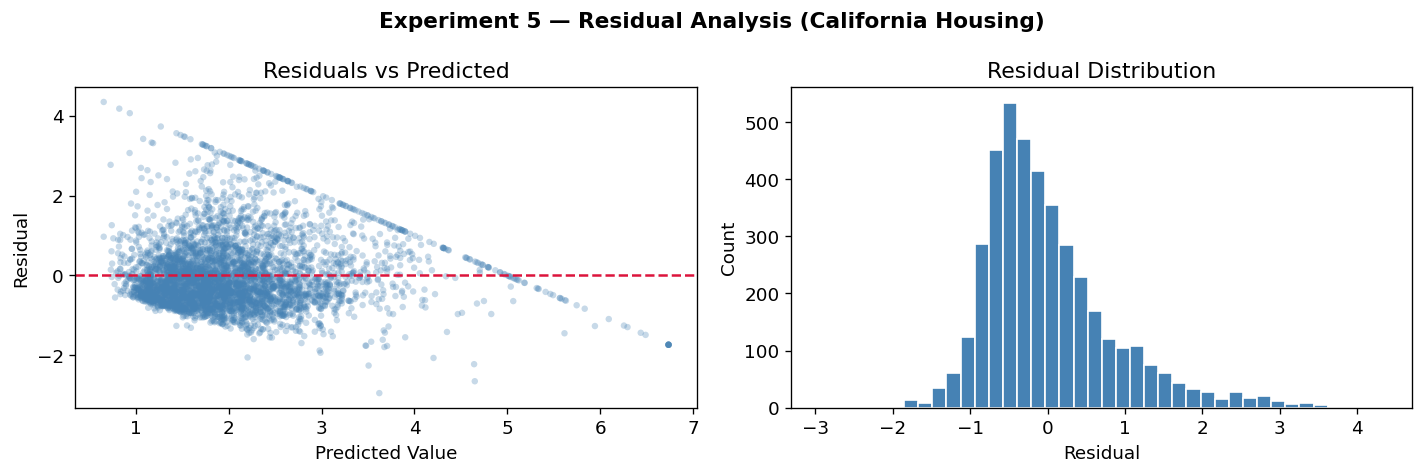

Mean residual : 0.0042  (should be ≈ 0)
Std residual  : 0.8421


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage import LinearRegression

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# ── 1. Simple 1D Fit — Visualizing the regression line ───────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — 1D Regression Line")
print("=" * 55)

rng = np.random.default_rng(42)
X_1d = rng.uniform(0, 10, size=(80, 1))
y_1d = 3.5 * X_1d.squeeze() + 7 + rng.normal(0, 2, 80)

model_1d = LinearRegression(method="normal")
model_1d.fit(X_1d, y_1d)

x_line = np.linspace(0, 10, 200).reshape(-1, 1)
y_line = model_1d.predict(x_line)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_1d, y_1d, alpha=0.6, edgecolors="k", s=40, label="Data")
ax.plot(x_line, y_line, color="crimson", linewidth=2, label=f"Fit: y = {model_1d.weights[0]:.2f}x + {model_1d.bias:.2f}")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Experiment 1 — Linear Regression Fit (1D)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Learned weight : {model_1d.weights[0]:.4f}  (true: 3.5)")
print(f"Learned bias   : {model_1d.bias:.4f}  (true: 7.0)")
print(f"R²             : {model_1d.score(X_1d, y_1d):.4f}\n")


# ── 2. Normal Equation vs Gradient Descent ────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Normal Equation vs Gradient Descent")
print("=" * 55)

X_cmp, y_cmp = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
X_cmp = StandardScaler().fit_transform(X_cmp)

model_ne = LinearRegression(method="normal")
model_gd = LinearRegression(method="gradient_descent", learning_rate=0.05, n_iters=500)
model_ne.fit(X_cmp, y_cmp)
model_gd.fit(X_cmp, y_cmp)

x_plot = np.linspace(X_cmp.min(), X_cmp.max(), 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, model, label, color in zip(
    axes,
    [model_ne, model_gd],
    ["Normal Equation", "Gradient Descent"],
    ["steelblue", "darkorange"]
):
    ax.scatter(X_cmp, y_cmp, alpha=0.4, edgecolors="k", s=25)
    ax.plot(x_plot, model.predict(x_plot), color=color, linewidth=2, label=label)
    ax.set_title(f"{label}  |  R² = {model.score(X_cmp, y_cmp):.4f}")
    ax.set_xlabel("X (standardized)")
    ax.set_ylabel("y")
    ax.legend()

plt.suptitle("Experiment 2 — Solver Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Normal Equation  — weight: {model_ne.weights[0]:.4f}, bias: {model_ne.bias:.4f}, R²: {model_ne.score(X_cmp, y_cmp):.4f}")
print(f"Gradient Descent — weight: {model_gd.weights[0]:.4f}, bias: {model_gd.bias:.4f}, R²: {model_gd.score(X_cmp, y_cmp):.4f}\n")


# ── 3. Gradient Descent Loss Curve ───────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 3 — Loss Convergence")
print("=" * 55)

learning_rates = [0.001, 0.01, 0.05, 0.1]
fig, ax = plt.subplots(figsize=(9, 4))
for lr in learning_rates:
    m = LinearRegression(method="gradient_descent", learning_rate=lr, n_iters=300)
    m.fit(X_cmp, y_cmp)
    ax.plot(m.loss_history, label=f"lr = {lr}")

ax.set_xlabel("Iteration")
ax.set_ylabel("MSE Loss")
ax.set_title("Experiment 3 — Loss Convergence for Different Learning Rates")
ax.legend()
plt.tight_layout()
plt.show()


# ── 4. Real Dataset — California Housing (single feature) ────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — California Housing Dataset")
print("=" * 55)

housing = fetch_california_housing()
X_h = housing.data[:, [0]]        # MedInc — most correlated with price
y_h = housing.target

X_tr, X_te, y_tr, y_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s  = sc.transform(X_te)

reg = LinearRegression(method="normal")
reg.fit(X_tr_s, y_tr)
y_pred = reg.predict(X_te_s)

r2  = reg.score(X_te_s, y_te)
mse = np.mean((y_te - y_pred) ** 2)
rmse = np.sqrt(mse)

print(f"Feature  : Median Income (MedInc)")
print(f"R²       : {r2:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}\n")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_te_s, y_te, alpha=0.3, s=15, edgecolors="none", label="Actual")
x_line = np.linspace(X_te_s.min(), X_te_s.max(), 200).reshape(-1, 1)
ax.plot(x_line, reg.predict(x_line), color="crimson", linewidth=2, label="Fit")
ax.set_xlabel("Median Income (standardized)")
ax.set_ylabel("House Value ($100k)")
ax.set_title(f"Experiment 4 — California Housing  |  R² = {r2:.4f}")
ax.legend()
plt.tight_layout()
plt.show()


# ── 5. Residual Analysis ──────────────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 5 — Residual Analysis")
print("=" * 55)

residuals = y_te - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, alpha=0.3, s=15, edgecolors="none", color="steelblue")
axes[0].axhline(0, color="crimson", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.suptitle("Experiment 5 — Residual Analysis (California Housing)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Mean residual : {np.mean(residuals):.4f}  (should be ≈ 0)")
print(f"Std residual  : {np.std(residuals):.4f}")